In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV files
train = pd.read_csv("datasets/train.csv")
valid = pd.read_csv("datasets/valid.csv")
test = pd.read_csv("datasets/test.csv")

# Label names
label_names = {
    0: "Fake",
    1: "Real"
}

# Add split column
train["split"] = "Train"
valid["split"] = "Validation"
test["split"] = "Test"

# Combine datasets
df = pd.concat([train, valid, test], ignore_index=True)

# Create readable label column
df["label_name"] = df["label"].map(label_names)

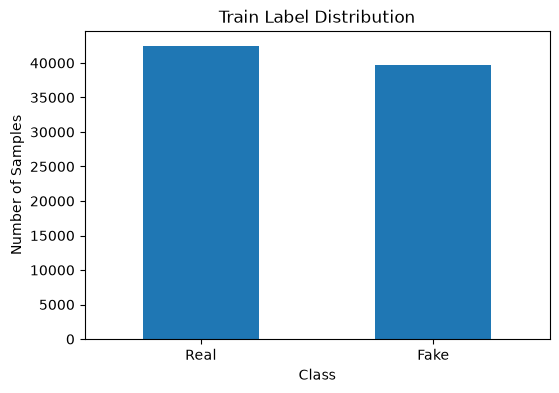


Train counts:
label
Real    42499
Fake    39713
Name: count, dtype: int64


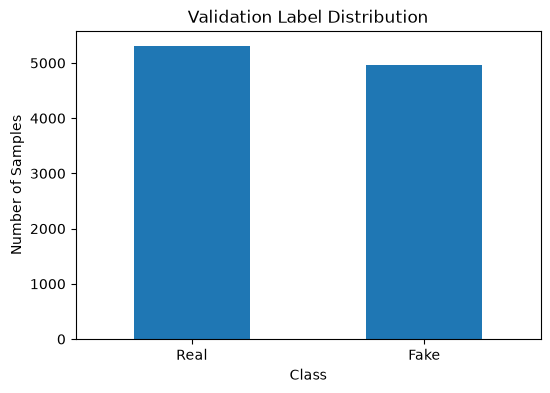


Validation counts:
label
Real    5313
Fake    4964
Name: count, dtype: int64


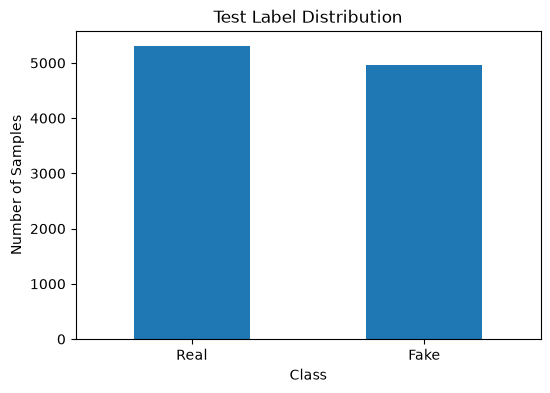


Test counts:
label
Real    5312
Fake    4965
Name: count, dtype: int64


In [6]:
for name, data in [("Train", train), ("Validation", valid), ("Test", test)]:
    counts = data["label"].map(label_names).value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind="bar")

    plt.title(f"{name} Label Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=0)
    plt.show()

    print(f"\n{name} counts:")
    print(counts)

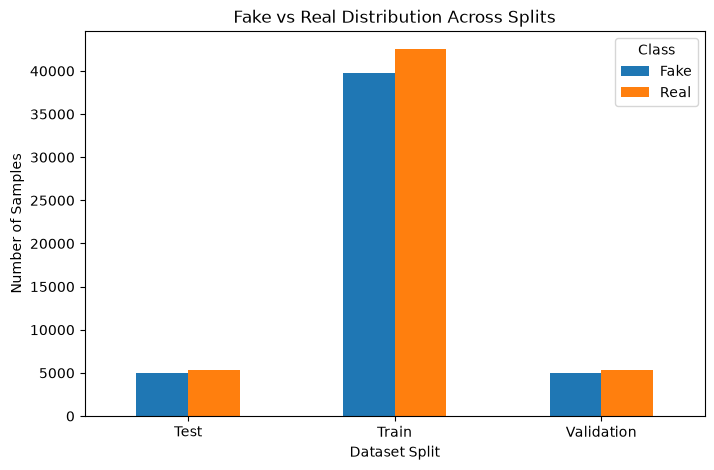

label_name   Fake   Real
split                   
Test         4965   5312
Train       39713  42499
Validation   4964   5313


In [7]:
split_label_counts = df.groupby(["split", "label_name"]).size().unstack()

split_label_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Fake vs Real Distribution Across Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.show()

print(split_label_counts)

        split label_name  percentage
0        Test       Real   51.688236
1        Test       Fake   48.311764
2       Train       Real   51.694400
3       Train       Fake   48.305600
4  Validation       Real   51.697966
5  Validation       Fake   48.302034


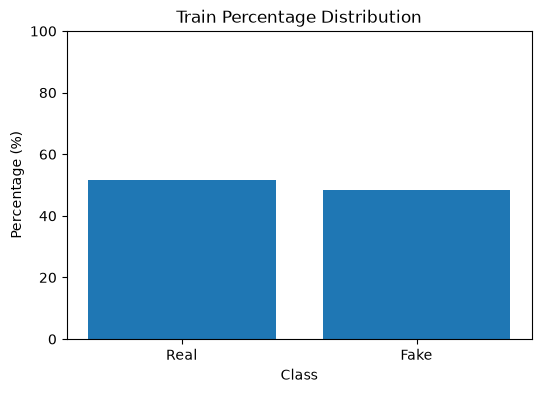

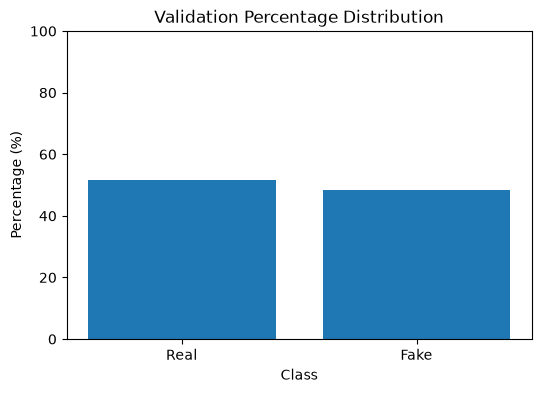

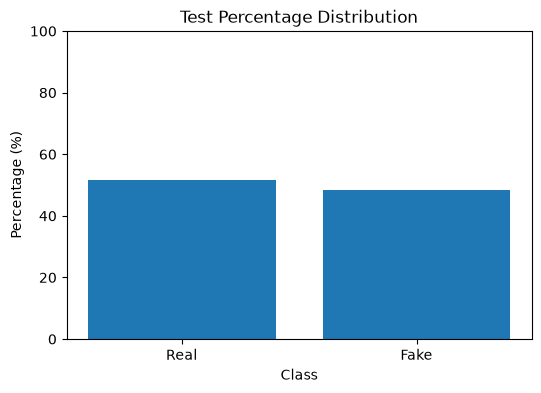

In [8]:
percentage_distribution = (
    df.groupby("split")["label_name"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .reset_index()
)

print(percentage_distribution)

for split in df["split"].unique():
    data = percentage_distribution[percentage_distribution["split"] == split]

    plt.figure(figsize=(6, 4))
    plt.bar(data["label_name"], data["percentage"])

    plt.title(f"{split} Percentage Distribution")
    plt.xlabel("Class")
    plt.ylabel("Percentage (%)")
    plt.ylim(0, 100)
    plt.show()

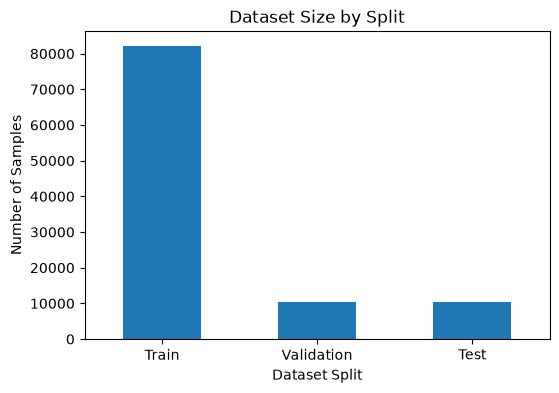

split
Train         82212
Validation    10277
Test          10277
Name: count, dtype: int64


In [9]:
split_sizes = df["split"].value_counts()

plt.figure(figsize=(6, 4))
split_sizes.plot(kind="bar")

plt.title("Dataset Size by Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.show()

print(split_sizes)

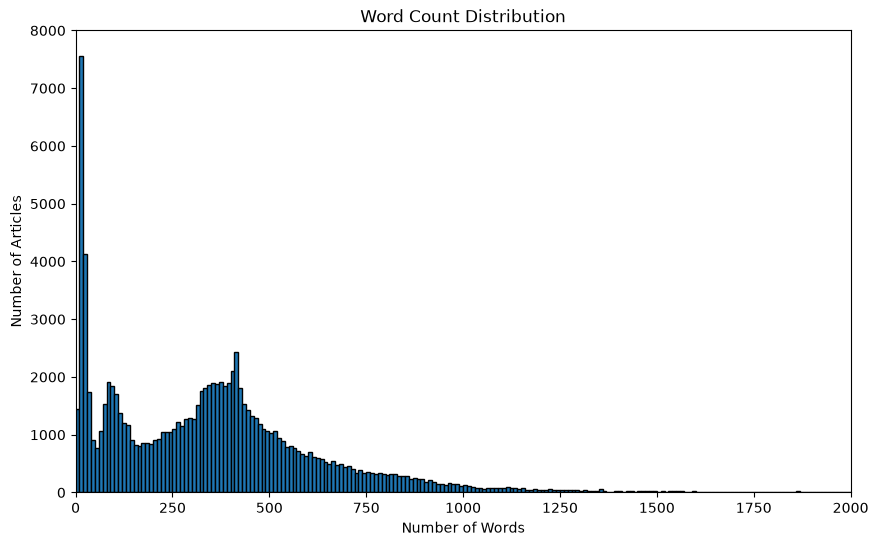

In [56]:
df["text_length"] = df["text"].astype(str).apply(len)
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

bins = range(0, 2610, 10)

plt.figure(figsize=(10, 6))
plt.hist(df["word_count"], bins=bins, edgecolor="black")

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Articles")
plt.xlim(0, 2000)
plt.ylim(0, 8000)
plt.show()

In [58]:
df[df["word_count"] < 20][["text", "label_name", "word_count"]].head(20)       
for threshold in range(0,501,10):

    count = (df["word_count"] < threshold).sum()

    percentage = count / len(df) * 100



    print(

        f"Below {threshold} words: "

        f"{count:,} rows ({percentage:.2f}%)"

    )

Below 0 words: 0 rows (0.00%)
Below 10 words: 1,451 rows (1.41%)
Below 20 words: 9,013 rows (8.77%)
Below 30 words: 13,149 rows (12.80%)
Below 40 words: 14,894 rows (14.49%)
Below 50 words: 15,800 rows (15.37%)
Below 60 words: 16,576 rows (16.13%)
Below 70 words: 17,637 rows (17.16%)
Below 80 words: 19,165 rows (18.65%)
Below 90 words: 21,082 rows (20.51%)
Below 100 words: 22,920 rows (22.30%)
Below 110 words: 24,634 rows (23.97%)
Below 120 words: 26,004 rows (25.30%)
Below 130 words: 27,199 rows (26.47%)
Below 140 words: 28,365 rows (27.60%)
Below 150 words: 29,282 rows (28.49%)
Below 160 words: 30,106 rows (29.30%)
Below 170 words: 30,914 rows (30.08%)
Below 180 words: 31,765 rows (30.91%)
Below 190 words: 32,621 rows (31.74%)
Below 200 words: 33,468 rows (32.57%)
Below 210 words: 34,370 rows (33.44%)
Below 220 words: 35,297 rows (34.35%)
Below 230 words: 36,349 rows (35.37%)
Below 240 words: 37,388 rows (36.38%)
Below 250 words: 38,444 rows (37.41%)
Below 260 words: 39,536 rows (38.

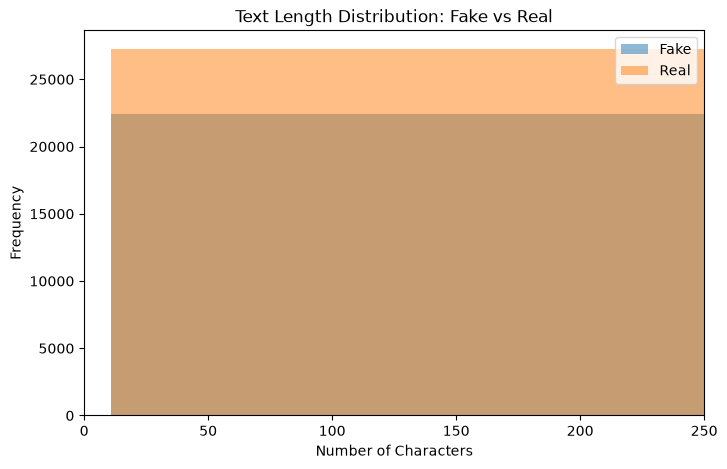

In [26]:
plt.figure(figsize=(8, 5))

for label in ["Fake", "Real"]:
    subset = df[df["label_name"] == label]
    plt.hist(subset["text_length"], bins=50, alpha=0.5, label=label)

plt.title("Text Length Distribution: Fake vs Real")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.xlim(0,250)
plt.legend()
plt.show()

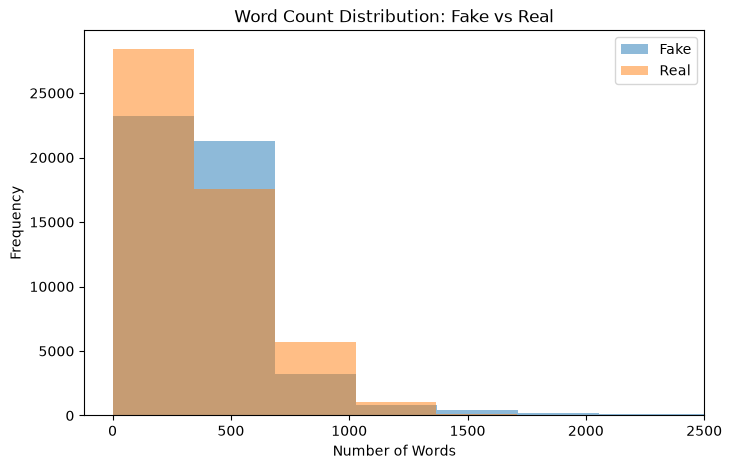

In [21]:
plt.figure(figsize=(8, 5))

for label in ["Fake", "Real"]:
    subset = df[df["label_name"] == label]
    plt.hist(
        subset["word_count"],
        bins=50,
        alpha=0.5,
        label=label
    )

plt.title("Word Count Distribution: Fake vs Real")
plt.xlim(-120, 2500)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()

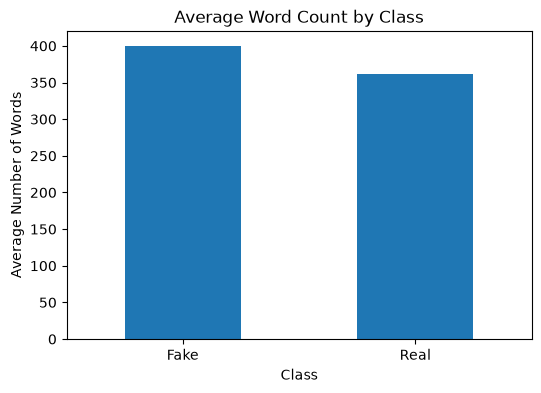

label_name
Fake    400.214153
Real    361.218395
Name: word_count, dtype: float64


In [18]:
avg_words = df.groupby("label_name")["word_count"].mean()

plt.figure(figsize=(6, 4))
avg_words.plot(kind="bar")

plt.title("Average Word Count by Class")
plt.xlabel("Class")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.show()

print(avg_words)

In [19]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) > 0:
    plt.figure(figsize=(8, 4))
    missing_values.plot(kind="bar")

    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45)
    plt.show()

    print(missing_values)
else:
    print("No missing values found.")

No missing values found.


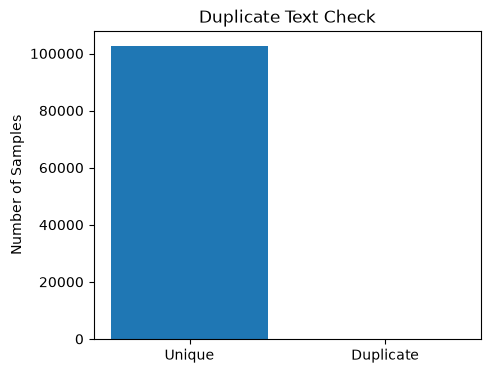

Duplicate texts: 0


In [20]:
duplicate_count = df["text"].duplicated().sum()

plt.figure(figsize=(5, 4))
plt.bar(["Unique", "Duplicate"], [len(df) - duplicate_count, duplicate_count])

plt.title("Duplicate Text Check")
plt.ylabel("Number of Samples")
plt.show()

print("Duplicate texts:", duplicate_count)